# CSCE 5218 - Deep Learning
# Name: Siva Kumar Reddy Surasani
# ID: 11702175
## Lab: Word2Vec from Scratch with Negative Sampling

**Estimated time:** 90-120 minutes  
**Environment:** Python 3.9+, NumPy, Matplotlib, scikit-learn  
**Submission:** Completed notebook with code outputs and written responses

In this lab, you will implement the skip-gram with negative sampling (SGNS) version of Word2Vec using NumPy. The corpus is embedded in the notebook, so no download is required.

> **Academic integrity:** You may use AI tools for clarification, debugging, and boilerplate. Your implementation choices, experiments, analysis, and written explanations must be your own. Disclose meaningful AI assistance.

### Learning objectives

By the end of the lab, you should be able to:

1. Convert tokenized text into skip-gram center-context training pairs.
2. Explain why negative sampling makes Word2Vec computationally efficient.
3. Derive and implement the SGNS loss and gradients.
4. Train and diagnose word embeddings using held-out loss.
5. Evaluate embeddings with nearest neighbors, analogies, and visualization.
6. Identify limitations of conclusions drawn from a small corpus.

### Mathematical model

For a center word $c$, a true context word $o$, and $K$ negative samples $n_1,\ldots,n_K$, SGNS minimizes

$$\mathcal{L}=-\log \sigma(u_o^T v_c)-\sum_{k=1}^{K}\log \sigma(-u_{n_k}^T v_c),$$

where $v_c$ is an input embedding, $u_o$ and $u_{n_k}$ are output embeddings, and $\sigma(x)=1/(1+e^{-x})$.

The positive term increases the center-context dot product. The negative terms decrease dot products for randomly sampled words.

In [2]:
import random
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
rng = np.random.default_rng(RANDOM_STATE)

print('NumPy:', np.__version__)

NumPy: 2.5.2


## 1. Build a controlled corpus

A controlled corpus lets us inspect what Word2Vec learns from repeated co-occurrence patterns. It is useful pedagogically, but it is not a substitute for a natural, large-scale corpus.

In [3]:
RAW_SENTENCES = [
    'king is a royal man', 'queen is a royal woman',
    'prince is a young royal man', 'princess is a young royal woman',
    'king and queen rule the kingdom', 'prince and princess live in the palace',
    'king wears a crown in the palace', 'queen wears a crown in the palace',
    'man and woman are adults', 'boy and girl are young',
    'paris is the capital of france', 'berlin is the capital of germany',
    'rome is the capital of italy', 'madrid is the capital of spain',
    'tokyo is the capital of japan', 'beijing is the capital of china',
    'france has the city paris', 'germany has the city berlin',
    'italy has the city rome', 'spain has the city madrid',
    'japan has the city tokyo', 'china has the city beijing',
    'dog is a loyal animal', 'cat is a quiet animal',
    'puppy is a young dog', 'kitten is a young cat',
    'dog and cat are common pets', 'puppy and kitten are young pets',
    'horse is a large animal', 'foal is a young horse',
    'apple is a sweet fruit', 'banana is a yellow fruit',
    'grape is a small fruit', 'orange is a citrus fruit',
    'red apple and yellow banana are fruit',
    'purple grape and orange citrus are fruit',
    'doctor works in a hospital', 'nurse works in a hospital',
    'teacher works in a school', 'student learns in a school',
    'doctor treats a patient', 'teacher teaches a student',
    'programmer writes computer code', 'computer executes code',
    'researcher studies data', 'scientist analyzes data',
    'river carries water', 'ocean contains water',
    'mountain is high', 'valley is low',
]

# Repeat patterns to create enough training observations, then shuffle reproducibly.
sentences = [s.lower().split() for s in RAW_SENTENCES for _ in range(20)]
rng.shuffle(sentences)

counts = Counter(token for sentence in sentences for token in sentence)
vocab = sorted(counts)
word_to_id = {word: i for i, word in enumerate(vocab)}
id_to_word = {i: word for word, i in word_to_id.items()}
encoded_sentences = [[word_to_id[w] for w in sentence] for sentence in sentences]

print(f'{len(sentences):,} sentences, {len(vocab)} vocabulary items')
print('Most common:', counts.most_common(10))

1,000 sentences, 92 vocabulary items
Most common: [('is', 440), ('a', 440), ('the', 320), ('and', 160), ('in', 140), ('young', 140), ('fruit', 120), ('capital', 120), ('of', 120), ('are', 120)]


### Task 1 - Inspect the corpus

1. Why will frequent function words such as `a`, `is`, and `the` dominate the training pairs?
2. Predict two semantic clusters the model should learn.  
3. Predict one relationship the model is unlikely to learn reliably from this corpus.

**Your response:**  
1.  Frequent function words such as a,  is, and the appear in many sentences. Because skip gram creates a training pair between each center word and every nearby context word, these frequent words participate in a large number of pair either in context or as a center. 
2. Two   semantic clusters model should learn are Royalty (Words like queen, king, prince, proncess, royal, and crown are related here with royalty), Geography (words like france, berlin, germany, italy and paris are frequently used in the corpus). These words are used in a similar context, and word2vec should place them near one another.
3. The model is unlikely to learn the relationship between the languages and the countries as the languages are not present in the corpus. It cannot learn relationships that are absent or represented with few examples.

## 2. Generate skip-gram training pairs

For each center token, pair it with every token within a fixed window. Do not pair a token position with itself.

In [5]:
def build_skipgram_pairs(encoded, window_size=2):
    # TODO: Return aligned int64 arrays of center IDs and context IDs.
    # For every token position, include all valid neighbors within the window,
    # but never pair a position with itself.
    center_ids = []
    context_ids = []
    for sentence in encoded:
        for center_position, center_word_id in enumerate(sentence):
            l_b = max(0, center_position - window_size)
            r_b = min(len(sentence), center_position + window_size + 1)

            for context_position in range(l_b, r_b):
                if context_position  == center_position:
                    continue
                center_ids.append(center_word_id)
                context_ids.append(sentence[context_position])
    return np.asarray(center_ids, dtype=np.int64), np.asarray(context_ids, dtype=np.int64)


centers, contexts = build_skipgram_pairs(encoded_sentences, window_size=2)
assert centers.shape == contexts.shape
assert len(centers) > 0

print(f'{len(centers):,} positive pairs')
for c, o in zip(centers[:10], contexts[:10]):
    print(f'{id_to_word[c]:>10s} -> {id_to_word[o]}')

14,320 positive pairs
  mountain -> is
  mountain -> high
        is -> mountain
        is -> high
      high -> mountain
      high -> is
     river -> carries
     river -> water
   carries -> river
   carries -> water


### Checkpoint 1

Explain how increasing `window_size` changes both the number and the meaning of the positive pairs.

**Your response:**  

Increasing window size increases the number of positive center-context pairs because each center word can be paired with more sorrounding words. A small window primarily captures local relationships, such as grammatical or syntactic patterns between the nearby words. A larger window will more distant words and can capture broader semantics and relationships. One of the downsides of having large window sizes is the weaker or less meaningful pairs between words in the same sentence.

Example

France has the city paris

With window size 1, the word gets has and city pairs
with window size 3 the same word the gets france, has, city and paris leading to a broader meaning.

## 3. Train/validation split and negative-sampling distribution

The original Word2Vec implementation samples negatives approximately according to unigram frequency raised to the $3/4$ power. This reduces the dominance of extremely frequent words while still sampling common words often.

In [7]:
order = rng.permutation(len(centers))
split = int(0.90 * len(order))
train_idx, val_idx = order[:split], order[split:]
train_centers, train_contexts = centers[train_idx], contexts[train_idx]
val_centers, val_contexts = centers[val_idx], contexts[val_idx]

def make_negative_distribution(counts, vocab, power=0.75):
    # TODO: Build the normalized unigram^power probability distribution.
    frequencies = np.array([counts[word] for word in vocab], dtype=np.float64)
    adjusted_freq = frequencies ** power
    probabilities = adjusted_freq / adjusted_freq.sum()
    return probabilities

negative_probs = make_negative_distribution(counts, vocab)
assert np.isclose(negative_probs.sum(), 1.0)

def sample_negatives(batch_size, k, positive_contexts, rng):
    negatives = rng.choice(len(vocab), size=(batch_size, k), p=negative_probs)
    invalid = negatives == positive_contexts[:, None]
    while invalid.any():
        negatives[invalid] = rng.choice(len(vocab), size=invalid.sum(), p=negative_probs)
        invalid = negatives == positive_contexts[:, None]
    return negatives

print('Train pairs:', len(train_centers), 'Validation pairs:', len(val_centers))

Train pairs: 12888 Validation pairs: 1432


### Task 2 - Reason about negative sampling

Why is a negative-sampling objective cheaper than a full softmax over a vocabulary of size $V$? If the embedding dimension is $d$, compare the approximate per-example complexity.

**Your response:**  

A softmax calculates a score and probability for every word in the vocab. With vocab size V and embedding dimension d, this requires complexity of O(Vd) for each training example. Negative sampling calculates scores only for the one positive context word and some randomly selected negative words, giving a much less complexity compared to softmax. 

For example, if there are k randomly selected negative samples, complexity is O((k+1) * d)

Suppose that V is 100, k is 5, and dimension d is 30 then using softmax we require 3000 operations whereas in negative sampling we select one positive context word and k(5) negative words, so the operations required are only 180.

## 4. Implement SGNS loss and gradients

Let $s^+=u_o^T v_c$ and $s_k^-=u_{n_k}^T v_c$. For one example:

$$\frac{\partial \mathcal{L}}{\partial s^+}=\sigma(s^+)-1, \qquad \frac{\partial \mathcal{L}}{\partial s_k^-}=\sigma(s_k^-).$$

In [8]:
def sigmoid(x):
    x = np.clip(x, -30.0, 30.0)
    return 1.0 / (1.0 + np.exp(-x))

def logsigmoid(x):
    return -np.logaddexp(0.0, -x)

class SGNS:
    def __init__(self, vocab_size, embedding_dim, rng):
        scale = 0.5 / embedding_dim
        self.W_in = rng.uniform(-scale, scale, size=(vocab_size, embedding_dim))
        self.W_out = np.zeros((vocab_size, embedding_dim), dtype=np.float64)

    def loss(self, center_ids, context_ids, negative_ids):
        v = self.W_in[center_ids]
        u_pos = self.W_out[context_ids]
        u_neg = self.W_out[negative_ids]
        pos_scores = np.sum(v * u_pos, axis=1)
        neg_scores = np.einsum('bd,bkd->bk', v, u_neg)
        return -np.mean(logsigmoid(pos_scores) + logsigmoid(-neg_scores).sum(axis=1))

    def step(self, center_ids, context_ids, negative_ids, learning_rate):
        # TODO: Implement one mini-batch SGNS update.
        # Required steps:
        # 1. Look up center, positive-context, and negative embeddings.
        v = self.W_in[center_ids]
        u_pos = self.W_out[context_ids]
        u_neg = self.W_out[negative_ids]
        
        # 2. Compute positive and negative scores and mean SGNS loss.
        pos_scores = np.sum(v * u_pos, axis=1)
        neg_scores = np.einsum('bd,bkd->bk', v, u_neg)
        loss = -np.mean(logsigmoid(pos_scores) + logsigmoid(-neg_scores).sum(axis=1))
        batch_size = len(center_ids)
        
        # 3. Use dL/ds_pos = sigmoid(s_pos)-1 and dL/ds_neg = sigmoid(s_neg).
        grad_pos_scores = (sigmoid(pos_scores) - 1.0) / batch_size
        grad_neg_scores = sigmoid(neg_scores) / batch_size
        grad_v = ( grad_pos_scores[:, None] * u_pos + np.sum( grad_neg_scores[:, :, None] * u_neg, axis=1))
        grad_u_pos = grad_pos_scores[:, None] * v
        grad_u_neg = (grad_neg_scores[:, :, None] * v[:, None, :])
        # 4. Accumulate repeated-ID updates with np.add.at.
        np.add.at(self.W_in,center_ids,-learning_rate * grad_v)
        np.add.at(self.W_out,context_ids,-learning_rate * grad_u_pos)
        np.add.at(self.W_out,negative_ids.reshape(-1),-learning_rate * grad_u_neg.reshape(-1, self.W_out.shape[1]))
        # 5. Return the scalar pre-update loss.
        return float(loss)

### Task 3 - Gradient check

Before long training, compare one analytic gradient with a finite-difference estimate. A relative error below approximately $10^{-4}$ is a useful sanity check.

In [9]:
def gradient_check():
    local_rng = np.random.default_rng(7)
    model = SGNS(vocab_size=8, embedding_dim=5, rng=local_rng)
    model.W_out[:] = local_rng.uniform(-0.1, 0.1, size=model.W_out.shape)
    c = np.array([1])
    o = np.array([2])
    n = np.array([[3, 4]])

    v = model.W_in[c].copy()
    u_pos = model.W_out[o].copy()
    u_neg = model.W_out[n].copy()
    pos = np.sum(v * u_pos, axis=1)
    neg = np.einsum('bd,bkd->bk', v, u_neg)
    analytic = ((sigmoid(pos) - 1)[:, None] * u_pos +
                np.sum(sigmoid(neg)[:, :, None] * u_neg, axis=1))[0, 0]

    eps = 1e-5
    original = model.W_in[1, 0]
    model.W_in[1, 0] = original + eps
    plus = model.loss(c, o, n)
    model.W_in[1, 0] = original - eps
    minus = model.loss(c, o, n)
    model.W_in[1, 0] = original
    numerical = (plus - minus) / (2 * eps)
    relative_error = abs(analytic - numerical) / max(1e-12, abs(analytic) + abs(numerical))
    return analytic, numerical, relative_error

analytic, numerical, relative_error = gradient_check()
print(f'analytic={analytic:.8f}, numerical={numerical:.8f}, relative error={relative_error:.2e}')
assert relative_error < 1e-4

analytic=-0.01041104, numerical=-0.01041104, relative error=1.36e-09


## 5. Train the embeddings

We monitor both training and held-out SGNS loss. The validation pairs come from the same controlled data-generating process, so the validation curve diagnoses optimization but does not establish real-world generalization.

Epoch 01: train=4.1538, val=4.1192
Epoch 05: train=2.4053, val=2.3300
Epoch 10: train=1.8036, val=1.7615
Epoch 15: train=1.5664, val=1.5482
Epoch 20: train=1.4369, val=1.4333
Epoch 25: train=1.3590, val=1.3667
Epoch 30: train=1.2954, val=1.3182
Epoch 35: train=1.2854, val=1.3049


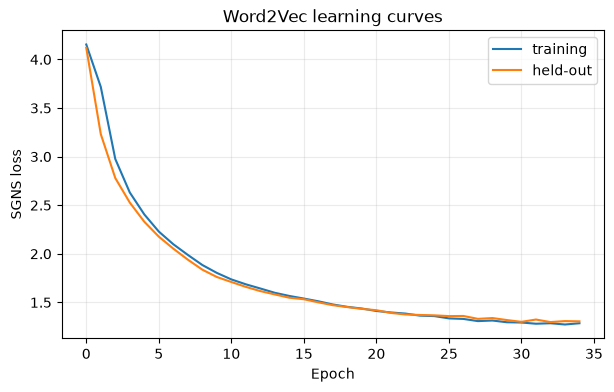

In [10]:
def train_word2vec(
    train_c, train_o, val_c, val_o, embedding_dim=30, num_negatives=5,
    epochs=35, batch_size=256, learning_rate=1.5, seed=42
):
    local_rng = np.random.default_rng(seed)
    model = SGNS(len(vocab), embedding_dim, local_rng)
    history = {'train': [], 'val': []}
    fixed_val_negatives = sample_negatives(len(val_c), num_negatives, val_o, local_rng)

    for epoch in range(epochs):
        permutation = local_rng.permutation(len(train_c))
        batch_losses = []
        for start in range(0, len(permutation), batch_size):
            idx = permutation[start:start + batch_size]
            c_batch, o_batch = train_c[idx], train_o[idx]
            negatives = sample_negatives(len(idx), num_negatives, o_batch, local_rng)
            batch_losses.append(model.step(c_batch, o_batch, negatives, learning_rate))

        train_loss = float(np.mean(batch_losses))
        val_loss = float(model.loss(val_c, val_o, fixed_val_negatives))
        history['train'].append(train_loss)
        history['val'].append(val_loss)
        if epoch == 0 or (epoch + 1) % 5 == 0:
            print(f'Epoch {epoch + 1:02d}: train={train_loss:.4f}, val={val_loss:.4f}')

    return model, history

model, history = train_word2vec(
    train_centers, train_contexts, val_centers, val_contexts
)

plt.figure(figsize=(7, 4))
plt.plot(history['train'], label='training')
plt.plot(history['val'], label='held-out')
plt.xlabel('Epoch')
plt.ylabel('SGNS loss')
plt.title('Word2Vec learning curves')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

### Checkpoint 2

1. Did both curves decrease?
2. If training loss decreases while held-out loss rises, what is the likely interpretation?
3. Why does a low SGNS loss not prove that the embeddings encode factual knowledge?

**Your response:**  

1. Yes both the curves showed decrease in losses. The training loss decreased from approximately 4.15 to 1.29, while the held-out loss decreases from 4.12 to 1.30. Curves remain close to each other, suggesting that the model learned from corpus patterns without clear evidence of overfitting.
2. If the training loss decreases while the held-out loss rises, the likely interpretation is overfitting. This means that the model is becoming better at fitting the training pairs but worse at generalizing the unseen pairs. Training should be stopped near the epoch where the held out loss reached its minimum in this case.
3. A low SGNS loss only shows that the model can distinguish observed center-context pairs from samples negative pairs. Word2Vec learns statistical co-occurrence patterns rather than explicitly verifying facts. Therefore, low loss does not prove that the embeddings contain correct factual knowledge, casual understanding, or reliable real world relationships.

## 6. Evaluate nearest neighbors and analogies

In [11]:
def normalized_embeddings(model):
    # Combining input and output embeddings often gives a useful representation.
    E = model.W_in + model.W_out
    return E / np.maximum(np.linalg.norm(E, axis=1, keepdims=True), 1e-12)

E = normalized_embeddings(model)

def nearest_neighbors(word, top_k=6, embeddings=E):
    query_id = word_to_id[word]
    scores = embeddings @ embeddings[query_id]
    ranking = np.argsort(-scores)
    return [(id_to_word[i], float(scores[i])) for i in ranking if i != query_id][:top_k]

for word in ['king', 'queen', 'paris', 'dog', 'doctor', 'fruit']:
    print(f'\n{word}:', nearest_neighbors(word))

def analogy(a, b, c, top_k=5, embeddings=E):
    # b - a + c; for example, king - man + woman -> queen
    query = embeddings[word_to_id[b]] - embeddings[word_to_id[a]] + embeddings[word_to_id[c]]
    query = query / max(np.linalg.norm(query), 1e-12)
    scores = embeddings @ query
    excluded = {word_to_id[a], word_to_id[b], word_to_id[c]}
    ranking = [i for i in np.argsort(-scores) if i not in excluded]
    return [(id_to_word[i], float(scores[i])) for i in ranking[:top_k]]

print('king - man + woman:', analogy('man', 'king', 'woman'))
print('paris - france + germany:', analogy('france', 'paris', 'germany'))


king: [('queen', 0.9371997315987626), ('wears', 0.9218744776030006), ('crown', 0.6400020781346554), ('rule', 0.5297888474853331), ('a', 0.49961177260229733), ('foal', 0.3959419285395596)]

queen: [('king', 0.9371997315987626), ('rule', 0.7580948496118802), ('wears', 0.7483613939501976), ('kingdom', 0.5148937911156007), ('and', 0.43036574917478176), ('crown', 0.42921561542766073)]

paris: [('berlin', 0.9989526799867583), ('beijing', 0.9989017032995189), ('rome', 0.9984231592544238), ('madrid', 0.9983463904841433), ('tokyo', 0.9983203966826343), ('city', 0.9284641567041204)]

dog: [('cat', 0.961048141476815), ('puppy', 0.8959004538100844), ('kitten', 0.8946102394576294), ('young', 0.8896733369400665), ('horse', 0.8575494856298319), ('royal', 0.7103983522736017)]

doctor: [('teacher', 0.9735899640769), ('treats', 0.9532553394033145), ('teaches', 0.9490707412270057), ('works', 0.9469516547485191), ('learns', 0.9297816272297378), ('student', 0.9260789799648069)]

fruit: [('sweet', 0.930935

### Task 4 - Quantitative intrinsic evaluation

Measure whether a related target appears among the top five neighbors. This metric is deliberately small and interpretable; it is not a standardized benchmark.

In [12]:
RELATED_PAIRS = [
    ('king', 'queen'), ('prince', 'princess'), ('dog', 'cat'),
    ('puppy', 'kitten'), ('paris', 'berlin'), ('france', 'germany'),
    ('doctor', 'teacher'), ('hospital', 'school'), ('apple', 'banana')
]

def related_at_k(model, pairs, k=5):
    embeddings = normalized_embeddings(model)
    hits = []
    for query, target in pairs:
        neighbors = [w for w, _ in nearest_neighbors(query, k, embeddings)]
        hits.append(target in neighbors)
        print(f'{query:>8s} -> {target:<10s} | {neighbors} | hit={hits[-1]}')
    return float(np.mean(hits))

score = related_at_k(model, RELATED_PAIRS, k=5)
print(f'\nRelated@5 = {score:.3f}')

    king -> queen      | ['queen', 'wears', 'crown', 'rule', 'a'] | hit=True
  prince -> princess   | ['princess', 'and', 'live', 'grape', 'apple'] | hit=True
     dog -> cat        | ['cat', 'puppy', 'kitten', 'young', 'horse'] | hit=True
   puppy -> kitten     | ['kitten', 'dog', 'cat', 'young', 'is'] | hit=True
   paris -> berlin     | ['berlin', 'beijing', 'rome', 'madrid', 'tokyo'] | hit=True
  france -> germany    | ['spain', 'japan', 'germany', 'italy', 'china'] | hit=True
  doctor -> teacher    | ['teacher', 'treats', 'teaches', 'works', 'learns'] | hit=True
hospital -> school     | ['school', 'learns', 'student', 'teacher', 'doctor'] | hit=True
   apple -> banana     | ['red', 'yellow', 'orange', 'grape', 'banana'] | hit=True

Related@5 = 1.000


## 7. Visualize selected embeddings

PCA is a projection: distances in two dimensions may distort relationships in the full embedding space.

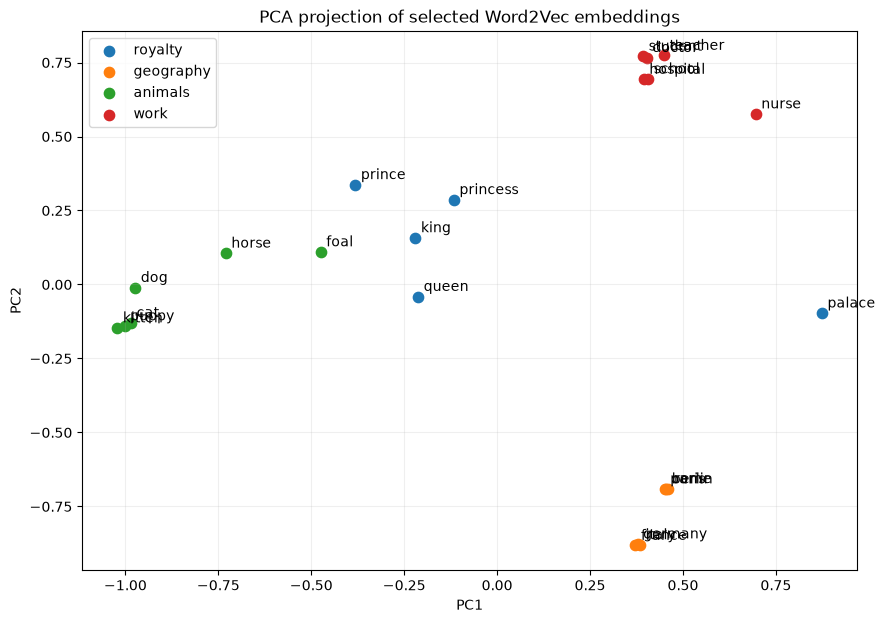

In [13]:
groups = {
    'royalty': ['king', 'queen', 'prince', 'princess', 'palace'],
    'geography': ['paris', 'france', 'berlin', 'germany', 'rome', 'italy'],
    'animals': ['dog', 'puppy', 'cat', 'kitten', 'horse', 'foal'],
    'work': ['doctor', 'nurse', 'hospital', 'teacher', 'student', 'school'],
}
selected = [word for words in groups.values() for word in words]
selected_ids = [word_to_id[w] for w in selected]
points = PCA(n_components=2).fit_transform(E[selected_ids])

plt.figure(figsize=(10, 7))
offset = 0
for label, words in groups.items():
    block = points[offset:offset + len(words)]
    plt.scatter(block[:, 0], block[:, 1], label=label, s=55)
    for word, (x, y) in zip(words, block):
        plt.annotate(word, (x, y), xytext=(4, 4), textcoords='offset points')
    offset += len(words)
plt.title('PCA projection of selected Word2Vec embeddings')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 8. Controlled experiment: context-window size

Train two otherwise identical models with window sizes 1 and 3. Record held-out loss, Related@5, qualitative neighbor differences, and runtime.

In [15]:
import time
experiment_results = []
for window in [1, 3]:
    exp_c, exp_o = build_skipgram_pairs(encoded_sentences, window_size=window)
    exp_order = np.random.default_rng(RANDOM_STATE).permutation(len(exp_c))
    exp_split = int(0.90 * len(exp_order))
    tr, va = exp_order[:exp_split], exp_order[exp_split:]
    start = time.perf_counter()
    exp_model, exp_history = train_word2vec(
        exp_c[tr], exp_o[tr], exp_c[va], exp_o[va],
        epochs=25, seed=RANDOM_STATE
    )
    runtime = time.perf_counter() - start
    exp_score = related_at_k(exp_model, RELATED_PAIRS, k=5)
    experiment_results.append({
        'window': window,
        'pairs': len(exp_c),
        'final_val_loss': exp_history['val'][-1],
        'related_at_5': exp_score,
        'runtime_sec': runtime,
    })

experiment_results

Epoch 01: train=4.1584, val=4.1571
Epoch 05: train=2.6808, val=2.6021
Epoch 10: train=1.8378, val=1.8485
Epoch 15: train=1.4314, val=1.4532
Epoch 20: train=1.2239, val=1.2558
Epoch 25: train=1.1204, val=1.1322
    king -> queen      | ['and', 'prince', 'puppy', 'boy', 'wears'] | hit=False
  prince -> princess   | ['puppy', 'grape', 'apple', 'boy', 'purple'] | hit=False
     dog -> cat        | ['woman', 'cat', 'young', 'yellow', 'man'] | hit=True
   puppy -> kitten     | ['prince', 'grape', 'apple', 'and', 'purple'] | hit=False
   paris -> berlin     | ['berlin', 'rome', 'beijing', 'madrid', 'tokyo'] | hit=True
  france -> germany    | ['china', 'italy', 'germany', 'japan', 'spain'] | hit=True
  doctor -> teacher    | ['teacher', 'works', 'nurse', 'treats', 'teaches'] | hit=True
hospital -> school     | ['school', 'a', 'patient', 'loyal', 'student'] | hit=True
   apple -> banana     | ['grape', 'red', 'puppy', 'prince', 'purple'] | hit=False
Epoch 01: train=4.1427, val=4.0289
Epoch 05:

[{'window': 1,
  'pairs': 8160,
  'final_val_loss': 1.1321577576944568,
  'related_at_5': 0.5555555555555556,
  'runtime_sec': 1.578680600039661},
 {'window': 3,
  'pairs': 18480,
  'final_val_loss': 1.4505709249681566,
  'related_at_5': 1.0,
  'runtime_sec': 3.2916771000018343}]

### Task 5 - Interpret the experiment

Report which window performed better under each metric. Explain why the result may differ between local syntactic relationships and broader semantic or topical relationships. Do not claim that one window is universally superior.

**Your response:**  

1. Positive Pairs: Window 3 with 8160 pairs provided more observations than window 1 with 18480 pairs.
2. Fial validatio loss of window one is less than window 3 with window 1 having 1.1321 and window 3 with 1.4505
3. Window size 3 perfomed better than window 1 incase of Related@5
4. Window size 1 completed training in 1.58 sec and window 3 completed in 3.2 sec mainly because it processed more positive pairs.


Details of observations

The model with window size 1 achieved the lower held-out SGNS loss of 1.132 compared with 1.451 for window size 3. However window size 3 performed better on the semantic related@5 evaluation, achieving 1.0 compared with 0.556 for window size 1. The larger window also geerated 18480 positive pair compared with the smaller window produving only 8160 pairs.

Window size 1 mainly captures local relationships between immediately adjacent words. This can help in learning the local word-order or syntactic relationships and makes its prediction objective narrower and leads to lower held-out loss. And also several semantically related targets- including queen, princess, kitten and banana didn't appear in the topi five in this window.

Window size 3 exposes each center word to more of the sentence. This helps it lear broader semantic and topical relationships, which explains why it achieved perfect related@5 performance. For example it connected king with queen, apple with banana accurately.


The loss values should be compared closely as the there is no superior one between two. Therefore the experiment does not establish that a particular window size is universally superior. The preferable window depends on whether the goal is to capture local syntactic context or broader semantic relationships.

## 9. Final analysis questions

Answer each in 3-5 sentences.

1. **Two embedding tables:** Why does SGNS learn both `W_in` and `W_out`? Why might we use `W_in`, `W_out`, or their sum at inference time?
2. **Polysemy:** This implementation assigns one vector to each word type. What happens to a word such as `bank` with multiple meanings?
3. **Bias:** How can social bias enter Word2Vec embeddings? Propose one diagnostic.
4. **Evaluation:** Why are nearest-neighbor examples and a two-dimensional PCA plot insufficient evidence of model quality?
5. **Extension:** Propose one experiment on a larger natural corpus, including a hypothesis, independent variable, dependent metric, and controlled variables.

**Your responses:**  

1. SGNS learns W_in to represent words when they act as center words and W_out to represent words when they act as context words. Separate tables are needed because the model gives a word different roles depending on whether it is predicting nearby words or being predicted as a nearby word. At inference time, W_in is commonly used as the main word representation, while W_out can be used when context-role information is more useful. Adding W_in + W_out incorporates information learned from both roles and may produce better similarity and nearest-neighbor results, although the best choice should be determined through evaluation.
2. This word2vec assigns only one embedding to every word type, so all occurreces of bank update the same vector. Consequently, the vector mixes context related to a financial bank with contexts related to a riverbannk. If one meaning occurs more frequently, that meaning may dominated the leared representation, otherwise the vector may become an imperfect average of both meanings. Conntextual embedding models can be best suited for producing the different representations for a word depending on its sorrounding sentence.
3. Social bias can enter Word2Vec embeddings through biased patterns in the training corpus. For example, if words describing men occur more frequently near science and leadership occupations while words describing women occur near caregiving roles, the embeddings may reproduce those associations. One diagnostic is to compare cosine similarities between gender terms and occupation terms, such as whether man is closer than woman to programmer, or whether woman is closer to nurse. These comparisons should be repeated across multiple word groups because a single pair is insufficient evidence of systematic bias.
4. Nearest-neighbor examples are usually based on a small, manually selected set of words and may highlight successful results while overlooking failures elsewhere in the vocabulary. A two-dimensional PCA plot compresses the original 30-dimensional embeddings into only two dimensions, which loses information and can distort distances between words. Neither method directly measures performance on an independent real-world task or standardized benchmark. Model quality should therefore also be evaluated using quantitative metrics, larger test sets, analogy benchmarks, and relevant downstream tasks.
5. I would train Word2Vec on a larger natural corpus while varying the number of negative samples used for each positive pair. My proposal is that increasing the number of negative samples will initially improve embedding quality by helping the model distinguish related from unrelated words, but the improvement will eventually level off while training time continues to increase. The independent variable would be the number of negative samples, such as 2, 5, 10, and 20, while the dependent metrics would be word-similarity performance, analogy accuracy, and training runtime. The corpus, preprocessing, context-window size, embedding dimension, epochs, learning rate, random seed, and evaluation dataset would remain controlled.

## Sources and AI Assistance

For learning more about skip-gram I have used below sources

1. https://www.geeksforgeeks.org/nlp/word-embeddings-in-nlp-comparison-between-cbow-and-skip-gram-models/
2. Also used chatgpt to get more examples of when to use cbow and skip gram

For other concepts

1. I have used chatgpt websearch to route to the reliable sources to know how various window sizes impact the models. Below is the link which extensively helped me get more details of training process and the window size concepts.

https://www.tensorflow.org/text/tutorials/word2vec?utm_source=chatgpt.com

2. Below is the tutorial in google colab that helped me in understanding more about skip gram negative sampling

https://colab.research.google.com/github/tensorflow/text/blob/master/docs/tutorials/word2vec.ipynb

3. I used chatgpt to help identify the causes of errors encountered while running my code and to support the debugging process.

## Submission checklist

- [ ] All implementation cells run from top to bottom.
- [ ] Gradient check passes.
- [ ] Learning-curve plot is included.
- [ ] Nearest-neighbor and analogy outputs are shown.
- [ ] Window-size experiment is completed and interpreted.
- [ ] Five final analysis questions are answered.
- [ ] Meaningful AI assistance is disclosed.